# 04 — Table-Aware Semantic Chunking (Milestone M2)

**DSML stage:** data preparation. **Input:** section-segmented elements (notebook 03).
**Output:** the chunk store `data/processed/chunks/nvda_chunks.parquet` — the atoms of provenance for the
whole system. Every future `EvidenceSpan` node is one of these chunks.

Design (per the feasibility studies — chunking mistakes are "the single largest driver of silent quality loss"):
- Chunks **never cross section boundaries**; each carries its full hierarchy (`company → filing → section → sub-heading`)
- **Tables become standalone chunks** (never merged into prose, never split)
- Prose accumulates whole elements up to a token budget; oversized elements split on sentence boundaries
- Chunk text is an **exact substring of the persisted canonical section text** (`char_start:char_end`) —
  byte-precise provenance without re-parsing HTML

Scope: only the sections the graph extracts from — Business (I.1), Risk Factors (I.1A / II.1A), MD&A (II.7 / I.2).

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import tiktoken

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SECTIONS_DIR = PROJECT_ROOT / "data" / "interim" / "sections"
CHUNKS_DIR = PROJECT_ROOT / "data" / "processed" / "chunks"
SECTION_TEXT_DIR = PROJECT_ROOT / "data" / "interim" / "section_texts"
CHUNKS_DIR.mkdir(parents=True, exist_ok=True)
SECTION_TEXT_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST = json.loads((PROJECT_ROOT / "data/raw/edgar/NVDA/manifest.json").read_text())
MANIFEST_BY_ACCN = {m["accession_no"]: m for m in MANIFEST}

ENC = tiktoken.get_encoding("cl100k_base")
TARGET_TOKENS = 700   # start a new chunk once the current one exceeds this
MAX_TOKENS = 1100     # hard cap — oversized single elements get sentence-split

# Sections worth extracting from, per form type
KEEP_SECTIONS = {
    "10-K": ["I.1", "I.1A", "II.7"],
    "10-Q": ["I.2", "II.1A"],
}

elements = pd.concat(
    [pd.read_parquet(p) for p in sorted(SECTIONS_DIR.glob("*.parquet"))], ignore_index=True
)
elements = elements[
    elements.apply(lambda r: r["section_id"] in KEEP_SECTIONS.get(r["form"], []), axis=1)
].reset_index(drop=True)
print(f"{len(elements):,} elements in scope across {elements['accession_no'].nunique()} filings")

801 elements in scope across 5 filings


## 1. Canonical section texts

Each section's elements joined with `\n\n` form the **canonical section text** — the provenance target that
`char_start`/`char_end` index into. Persisted so citations can be re-verified without re-parsing HTML.

In [2]:
SEP = "\n\n"
section_texts = []
element_offsets = {}  # (accession, section_id) -> list of (element_row_index, char_start, char_end)

for (accn, section_id), grp in elements.groupby(["accession_no", "section_id"], sort=False):
    grp = grp.sort_values("element_index")
    offsets, cursor, parts = [], 0, []
    for row_idx, row in grp.iterrows():
        start = cursor
        parts.append(row["text"])
        cursor += len(row["text"])
        offsets.append((row_idx, start, cursor))
        cursor += len(SEP)
    full_text = SEP.join(parts)
    element_offsets[(accn, section_id)] = offsets
    section_texts.append({
        "accession_no": accn,
        "section_id": section_id,
        "form": grp.iloc[0]["form"],
        "filing_date": grp.iloc[0]["filing_date"],
        "section_title": grp.iloc[0]["section_title"],
        "text": full_text,
        "n_chars": len(full_text),
    })

section_texts_df = pd.DataFrame(section_texts)
section_texts_df.to_parquet(SECTION_TEXT_DIR / "nvda_section_texts.parquet", index=False)
section_texts_df[["accession_no", "section_id", "form", "n_chars"]].head(8)

,accession_no,section_id,form,n_chars
0,0001045810-23-000017,I.1,10-K,52924
1,0001045810-23-000017,I.1A,10-K,87159
2,0001045810-23-000017,II.7,10-K,38038
3,0001045810-24-000029,I.1,10-K,51355
4,0001045810-24-000029,I.1A,10-K,106367
5,0001045810-24-000029,II.7,10-K,39801
6,0001045810-25-000023,I.1,10-K,54546
7,0001045810-25-000023,I.1A,10-K,110309


## 2. The chunker

Walks a section's elements in order, tracking the latest sub-heading (`TitleElement`) as metadata.
Prose accumulates until `TARGET_TOKENS`; a `TableElement` always flushes the current chunk and becomes its
own chunk; an element longer than `MAX_TOKENS` is split at sentence boundaries (offsets preserved).

In [3]:
SENTENCE_RE = re.compile(r"(?<=[.!?])\s+")

def n_tokens(text: str) -> int:
    return len(ENC.encode(text, disallowed_special=()))

def split_oversized(text: str, abs_start: int) -> list[tuple[str, int, int]]:
    """Split one long element into <=MAX_TOKENS pieces at sentence boundaries.
    Returns (piece_text, abs_char_start, abs_char_end) with offsets into the section text."""
    pieces, buf, buf_start, cursor = [], [], abs_start, abs_start
    for sent in SENTENCE_RE.split(text):
        candidate = " ".join(buf + [sent])
        if buf and n_tokens(candidate) > MAX_TOKENS:
            joined = " ".join(buf)
            pieces.append((joined, buf_start, buf_start + len(joined)))
            buf, buf_start = [sent], cursor
        else:
            buf.append(sent)
        cursor += len(sent) + 1  # +1 for the split whitespace
    if buf:
        joined = " ".join(buf)
        pieces.append((joined, buf_start, min(buf_start + len(joined), abs_start + len(text))))
    return pieces

def chunk_section(accn: str, section_id: str, section_row: pd.Series) -> list[dict]:
    grp = elements.loc[[i for i, _, _ in element_offsets[(accn, section_id)]]]
    offs = {i: (s, e) for i, s, e in element_offsets[(accn, section_id)]}
    meta = MANIFEST_BY_ACCN[accn]
    chunks, buf, sub_heading = [], [], None  # buf: list of (row, start, end)

    def flush(kind: str):
        if not buf:
            return
        start, end = buf[0][1], buf[-1][2]
        text = section_row["text"][start:end]
        chunks.append({
            "ticker": "NVDA", "cik": meta["cik"], "form": meta["form"],
            "filing_date": meta["filing_date"], "accession_no": accn,
            "section_id": section_id, "section_title": section_row["section_title"],
            "sub_heading": sub_heading, "kind": kind, "text": text,
            "char_start": start, "char_end": end, "n_tokens": n_tokens(text),
            "source_url": meta["source_url"],
        })
        buf.clear()

    for row_idx, row in grp.iterrows():
        start, end = offs[row_idx]
        if row["element_type"] == "TitleElement":
            flush("prose")
            sub_heading = row["text"][:150]
            continue
        if row["element_type"] == "TableElement":
            flush("prose")
            buf.append((row_idx, start, end)); flush("table")
            continue
        if n_tokens(row["text"]) > MAX_TOKENS:  # oversized prose element
            flush("prose")
            for piece, ps, pe in split_oversized(row["text"], start):
                buf.append((row_idx, ps, pe)); flush("prose")
            continue
        buf.append((row_idx, start, end))
        if n_tokens(section_row["text"][buf[0][1]:buf[-1][2]]) >= TARGET_TOKENS:
            flush("prose")
    flush("prose")
    return chunks

In [4]:
all_chunks = []
for _, srow in section_texts_df.iterrows():
    all_chunks.extend(chunk_section(srow["accession_no"], srow["section_id"], srow))

chunks_df = pd.DataFrame(all_chunks)
chunks_df.insert(0, "chunk_id", [
    f"{r.accession_no}:{r.section_id}:{i:04d}"
    for i, r in enumerate(chunks_df.itertuples())
])
chunks_path = CHUNKS_DIR / "nvda_chunks.parquet"
chunks_df.to_parquet(chunks_path, index=False)
print(f"{len(chunks_df):,} chunks → {chunks_path.relative_to(PROJECT_ROOT)}")
chunks_df.groupby(["form", "section_id", "kind"]).size().unstack(fill_value=0)

439 chunks → data\processed\chunks\nvda_chunks.parquet


kind             prose  table
form section_id              
10-K I.1           101      4
     I.1A          140      0
     II.7          118     36
10-Q I.2            21     10
     II.1A           9      0

## 3. EDA — token distribution and section coverage

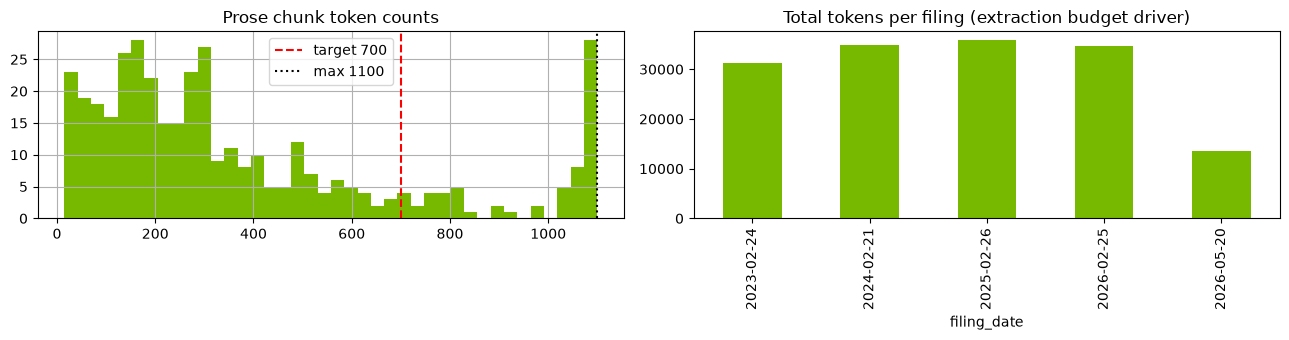

Corpus: 150,185 tokens across 439 chunks (≈$0.45 input cost per full extraction pass at $3/Mtok)


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
chunks_df[chunks_df["kind"] == "prose"]["n_tokens"].hist(bins=40, ax=axes[0], color="#76b900")
axes[0].axvline(TARGET_TOKENS, color="red", ls="--", label=f"target {TARGET_TOKENS}")
axes[0].axvline(MAX_TOKENS, color="black", ls=":", label=f"max {MAX_TOKENS}")
axes[0].set_title("Prose chunk token counts"); axes[0].legend()
chunks_df.groupby("filing_date")["n_tokens"].sum().plot.bar(ax=axes[1], color="#76b900")
axes[1].set_title("Total tokens per filing (extraction budget driver)")
plt.tight_layout(); plt.show()

total_tokens = chunks_df["n_tokens"].sum()
print(f"Corpus: {total_tokens:,} tokens across {len(chunks_df)} chunks "
      f"(≈${total_tokens / 1e6 * 3:.2f} input cost per full extraction pass at $3/Mtok)")

In [6]:
# Provenance spot check: chunk text must be an exact substring of its canonical section text
sample = chunks_df.sample(5, random_state=42)
st_lookup = section_texts_df.set_index(["accession_no", "section_id"])["text"]
for _, c in sample.iterrows():
    canonical = st_lookup[(c["accession_no"], c["section_id"])]
    assert canonical[c["char_start"]:c["char_end"]] == c["text"]
print("Provenance OK — 5/5 sampled chunks are exact substrings at their recorded offsets")
sample[["chunk_id", "section_id", "sub_heading", "kind", "n_tokens"]]

Provenance OK — 5/5 sampled chunks are exact substrings at their recorded offsets


,chunk_id,section_id,sub_heading,kind,n_tokens
265,0001045810-25-000023:I.1A:0265,I.1A,We may have exposure to additional tax liabili...,prose,578
78,0001045810-23-000017:II.7:0078,II.7,Change in Accounting Estimate,prose,157
347,0001045810-26-000021:I.1A:0347,I.1A,We may not be able to realize the potential be...,prose,887
255,0001045810-25-000023:I.1A:0255,I.1A,"We are subject to complex laws, rules, regulat...",prose,1057
327,0001045810-26-000021:I.1:0327,I.1,Information About Our Executive Officers,table,66


## 4. Data dictionary — `data/processed/chunks/nvda_chunks.parquet`

| column | meaning |
|---|---|
| `chunk_id` | `{accession_no}:{section_id}:{seq}` — the future `EvidenceSpan` key |
| `ticker`, `cik`, `form`, `filing_date`, `accession_no` | filing provenance (joins to manifest) |
| `section_id`, `section_title`, `sub_heading` | hierarchy: section + nearest sub-heading (metadata, not baked into `text`) |
| `kind` | `prose` \| `table` — tables are standalone, never split or merged |
| `text` | exact substring of the canonical section text |
| `char_start`, `char_end` | offsets into `data/interim/section_texts/` → re-verifiable citations |
| `n_tokens` | cl100k_base count (budgeting for extraction + embedding) |
| `source_url` | SEC.gov URL for the UI citation link |

In [7]:
# --- M2 assertion cell ---
prose = chunks_df[chunks_df["kind"] == "prose"]
assert (prose["n_tokens"] <= MAX_TOKENS + 50).all(), "prose chunk exceeds hard cap"
assert chunks_df["chunk_id"].is_unique
assert chunks_df["text"].str.len().gt(0).all()
assert set(chunks_df["section_id"]).issubset({"I.1", "I.1A", "II.7", "I.2", "II.1A"})
assert chunks_df["text"].str.contains("TSMC", case=False).any(), "expected TSMC mentions in NVDA filings"
assert chunks_df["text"].str.contains("export control", case=False).any(), "expected export-control mentions"
for accn in chunks_df["accession_no"].unique():
    assert len(chunks_df[chunks_df["accession_no"] == accn]) > 20, f"{accn}: too few chunks"
print(f"M2 (chunking) OK — {len(chunks_df)} chunks, provenance verified, TSMC + export-control content present")

M2 (chunking) OK — 439 chunks, provenance verified, TSMC + export-control content present
